## Level 2 - Task 1: Table Booking & Online Delivery Analysis


In [11]:
import pandas as pd
df = pd.read_csv('/content/Dataset .csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [12]:
df["Has Table booking"].value_counts(normalize=True) * 100

,proportion
Has Table booking,
No,87.875615
Yes,12.124385


In [13]:
df["Has Online delivery"].value_counts(normalize=True) * 100

,proportion
Has Online delivery,
No,74.337766
Yes,25.662234


### Table Booking and Online Delivery Analysis

The analysis shows that only about 12.12% of restaurants offer table booking, while the majority (87.87%) do not provide this service.

In contrast, online delivery is offered by approximately 25.66% of restaurants, which is higher than table booking but still not available in most restaurants.

This indicates that while online delivery is gaining popularity, traditional dining without booking or delivery remains dominant.

In [14]:
df.groupby("Has Table booking")["Aggregate rating"].mean()

,Aggregate rating
Has Table booking,
No,2.559359
Yes,3.441969


### Rating Comparison Based on Table Booking

The analysis shows that restaurants offering table booking have a higher average rating (3.44) compared to those without table booking (2.56).

This suggests that restaurants with table booking services tend to provide a better customer experience and are generally rated higher.

In [15]:
df.groupby("Price range")["Has Online delivery"].value_counts(normalize=True) * 100

Price range  Has Online delivery
1            No                     84.225923
             Yes                    15.774077
2            No                     58.689367
             Yes                    41.310633
3            No                     70.809659
             Yes                    29.190341
4            No                     90.955631
             Yes                     9.044369
Name: proportion, dtype: float64

### Online Delivery and Price Range Analysis

The analysis shows that online delivery availability varies across different price ranges.

Mid-range restaurants (Price range 2) have the highest percentage of online delivery services, indicating their focus on accessibility and convenience.

In contrast, high-end restaurants (Price range 4) have the lowest availability of online delivery, suggesting that they prioritize dine-in experiences over delivery services.

Budget restaurants (Price range 1) also show relatively low delivery availability.

## Level 2 - Task 2: Price Range Analysis

In [16]:
df["Price range"].value_counts()

,count
Price range,
1,4444
2,3113
3,1408
4,586


### Most Common Price Range

The analysis shows that the majority of restaurants fall under Price range 1, indicating that most restaurants are budget-friendly.

As the price range increases, the number of restaurants decreases significantly, with very few restaurants in the high-end category (Price range 4).

In [17]:
df.groupby("Price range")["Aggregate rating"].mean()

,Aggregate rating
Price range,
1,1.999887
2,2.941054
3,3.683381
4,3.817918


### Average Rating by Price Range

The analysis shows that the average rating increases with the price range of restaurants.

Budget restaurants (Price range 1) have the lowest average rating, while high-end restaurants (Price range 4) have the highest ratings.

This suggests that higher-priced restaurants tend to offer better quality, service, and overall customer experience.

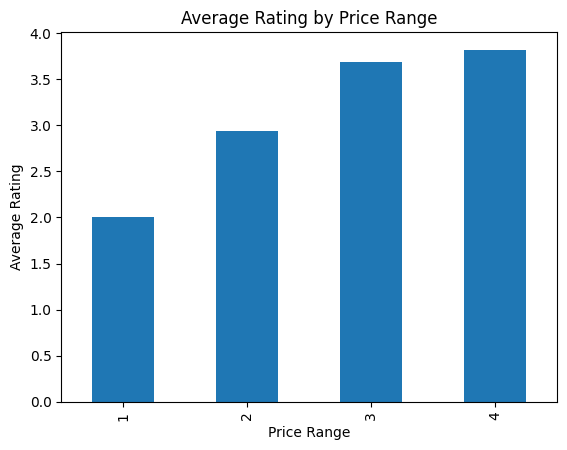

In [18]:
import matplotlib.pyplot as plt

df.groupby("Price range")["Aggregate rating"].mean().plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()

## Level 2 - Task 3: Feature Engineering

In [19]:
# Length of restaurant name
df["Name Length"] = df["Restaurant Name"].apply(len)

# Has Table Booking (convert Yes/No to 1/0)
df["Table Booking"] = df["Has Table booking"].map({"Yes": 1, "No": 0})

# Has Online Delivery (convert Yes/No to 1/0)
df["Online Delivery"] = df["Has Online delivery"].map({"Yes": 1, "No": 0})

### Feature Engineering

New features were created to enhance the dataset for better analysis.

The length of restaurant names was calculated as a new feature.

Categorical variables such as "Has Table booking" and "Has Online delivery" were converted into numerical format (0 and 1) to make them suitable for further analysis and modeling.

These transformations help in improving the usability of the dataset.